## Loading packages

In [ ]:
import os

import pandas as pd  # used for data handling
import seaborn as sns  # used for statistical data visualization
import plotly.io as pio  # used to set the default plotly renderer

pio.renderers.default = (
    "notebook"  # set the default plotly renderer to "notebook" (necessary for quarto to render the plots)
)

## Loading the dataset

The dataset is available online in form of two `csv` files.

[//]: # TODO - publish dataset, link here, rerun analysis and compare
Source: tba

In [12]:
path_data = os.path.join("..", "data", "assets", "act3")

df_machinedata = pd.read_csv(os.path.join(path_data, "simulated_opcua_machinedata.csv"))
df_postinspection = pd.read_csv(os.path.join(path_data, "simulated_opcua_postinspection.csv"))

## Quick check data integrity

In [13]:
df_machinedata

,Air temperature [K],Attached Weight [mg],Position x [mm],Position y [mm],Process step,Process temperature [K],Speed [mm/s],Speed next [mm/s],timestamp,cycle
0,24.606632,0.000000,68.124535,65.789373,0,31.483151,100.000000,0.000000,2025-12-15T14:07:38.673121,1
1,23.958676,417.173109,68.124535,65.789373,1,32.524906,0.000000,70.265797,2025-12-15T14:07:39.867643,1
2,25.858914,417.173109,150.000000,150.000000,2,30.295518,70.265797,0.000000,2025-12-15T14:07:40.387643,1
3,24.852862,0.000000,150.000000,150.000000,3,31.388396,0.000000,100.000000,2025-12-15T14:07:42.079185,1
4,22.561051,0.000000,233.123000,123.150991,0,31.371059,100.000000,0.000000,2025-12-15T14:07:42.099185,2
...,...,...,...,...,...,...,...,...,...,...
99995,8.845527,0.000000,150.000000,150.000000,3,15.806539,0.000000,100.000000,2025-12-16T22:31:16.208835,24999
99996,11.444153,0.000000,104.567248,264.506366,0,16.093692,100.000000,0.000000,2025-12-16T22:31:16.228835,25000
99997,9.295340,480.272350,104.567248,264.506366,1,14.099441,0.000000,82.389574,2025-12-16T22:31:17.480738,25000
99998,9.364440,480.272350,150.000000,150.000000,2,15.774856,82.389574,0.000000,2025-12-16T22:31:18.000738,25000


In [14]:
df_postinspection

,cycle,error_x,error_y
0,1,0.926427,0.952850
1,2,-1.071760,0.346182
2,3,0.935244,0.958105
3,4,-1.330248,2.396199
4,5,1.269216,-0.984624
...,...,...,...
24995,24996,-1.772174,-1.043073
24996,24997,2.629789,0.122697
24997,24998,-1.865141,1.091747
24998,24999,-0.679947,1.311611


In [16]:
df = df_machinedata.merge(df_postinspection, on="cycle", how="left")
df

,Air temperature [K],Attached Weight [mg],Position x [mm],Position y [mm],Process step,Process temperature [K],Speed [mm/s],Speed next [mm/s],timestamp,cycle,error_x,error_y
0,24.606632,0.000000,68.124535,65.789373,0,31.483151,100.000000,0.000000,2025-12-15T14:07:38.673121,1,0.926427,0.952850
1,23.958676,417.173109,68.124535,65.789373,1,32.524906,0.000000,70.265797,2025-12-15T14:07:39.867643,1,0.926427,0.952850
2,25.858914,417.173109,150.000000,150.000000,2,30.295518,70.265797,0.000000,2025-12-15T14:07:40.387643,1,0.926427,0.952850
3,24.852862,0.000000,150.000000,150.000000,3,31.388396,0.000000,100.000000,2025-12-15T14:07:42.079185,1,0.926427,0.952850
4,22.561051,0.000000,233.123000,123.150991,0,31.371059,100.000000,0.000000,2025-12-15T14:07:42.099185,2,-1.071760,0.346182
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,8.845527,0.000000,150.000000,150.000000,3,15.806539,0.000000,100.000000,2025-12-16T22:31:16.208835,24999,-0.679947,1.311611
99996,11.444153,0.000000,104.567248,264.506366,0,16.093692,100.000000,0.000000,2025-12-16T22:31:16.228835,25000,0.684341,-1.724778
99997,9.295340,480.272350,104.567248,264.506366,1,14.099441,0.000000,82.389574,2025-12-16T22:31:17.480738,25000,0.684341,-1.724778
99998,9.364440,480.272350,150.000000,150.000000,2,15.774856,82.389574,0.000000,2025-12-16T22:31:18.000738,25000,0.684341,-1.724778


## Visualize Errors

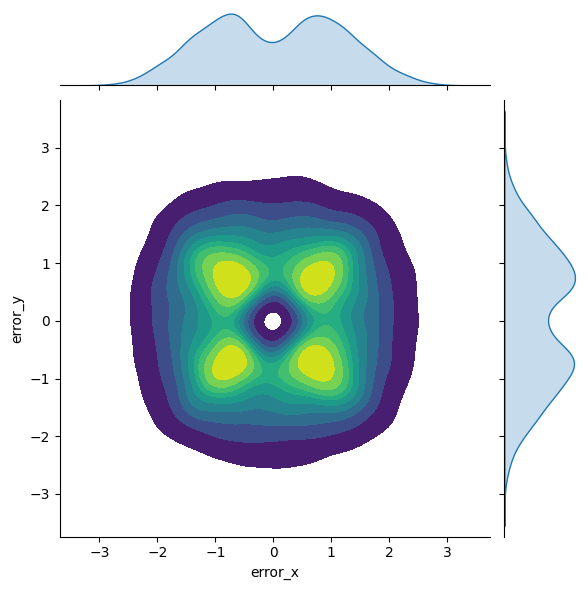

In [20]:
sns.jointplot(data=df_postinspection, x="error_x", y="error_y", kind="kde", fill=True, cmap="viridis")

This is a rather interesting error distribution.

@{sec-act3-selfstudy2} will guide you through the optimization process aimed at reducing these errors and improving overall process accuracy.